# CHICAGO CAR CRASH PREDICTION AND ANALYSIS

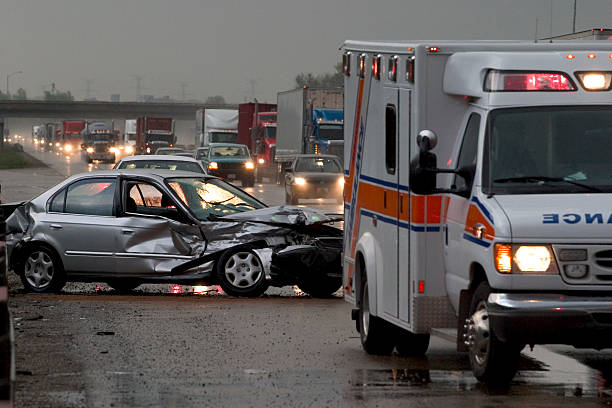


# BUSINESS UNDERSTANDING

## PROBLEM STATEMENT
Traffic accidents are a major concern in Chicago. Understanding the conditions that lead to severe crashes will help the Vehicle safety board.
This project aims to build a classification model that predicts whether a car crash will result in injuries based on environmental factors or other factors. The insights from this model will help identify high risk conditions and implement preventive measures to imrove road safety.

## Stakeholders
- Vehicle safety board
   - Responsible for road safety
   - Implement safety programs
   - They will use this model to identify high risk driving conditions and issue weather related alerts 
- City of Chicago
   - Responsible for infrastructure



## Key Questions
1. What factors contribute to most crashes?
2. Under what conditions are crashes most likely to result in injuries?
3. Can we predict whether a crash will result in injuries based on environmental conditions?
4. Can we predict the primary contributory cause of accidents?



# DATA UNDERSTANDING

The dataset we are using has been obtained from kaggle, it contains car crashes in chicago from 2019 to 2022. Its particulary useful because it includes car crash variables and environmental factors that influence crash outcomes. It allows us to analyze patterns in traffic accidents.

#### Importing libraries

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

#### Loading the dataset

In [73]:
df=pd.read_csv("chicago_2019_2022.csv")

C:\Users\Dell\AppData\Local\Temp\ipykernel_25140\2883874868.py:1: DtypeWarning: Columns (53) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("chicago_2019_2022.csv")


#### Loads the dataset into pandas dataframe so that we can explore and manipulate it

#### Data inspection

In [74]:
df.head()

,id,crash_date,crash_time,town,city,state,country,total_injured,total_killed,injury_incapacitated,...,windgust,windspeed,winddir,pressure,visibility,cloudcover,conditions,sunrise,sunset,moonphase
0,200319661,07/18/19,10:35,harwood heights,chicago,illinois,usa,0,0,0,...,\N,6.9,193.0,1013.9,1.8,54.6,"Rain, Partially cloudy",5:31:20,20:23:09,0.56
1,200320852,07/21/19,13:45,englewood,chicago,illinois,usa,0,0,0,...,\N,11.4,3.0,1013.3,7.4,87.4,"Rain, Partially cloudy",5:33:58,20:19:28,0.66
2,200320894,07/21/19,16:00,cragin,chicago,illinois,usa,0,0,0,...,\N,13.7,17.0,1013.6,9.9,58.2,"Rain, Partially cloudy",5:33:54,20:20:12,0.66
3,200320909,07/21/19,16:45,cragin,chicago,illinois,usa,0,0,0,...,\N,13.7,17.0,1013.6,9.9,58.3,"Rain, Partially cloudy",5:33:53,20:20:10,0.66
4,200320967,07/21/19,23:05,cicero,chicago,illinois,usa,0,0,0,...,\N,4.9,342.0,1018.4,9.9,0.0,Clear,5:34:53,20:19:06,0.69


##### Inspecting the shape of our dataset

In [75]:
df.shape

(372062, 65)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372062 entries, 0 to 372061
Data columns (total 65 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   id                                372062 non-null  int64  
 1   crash_date                        372062 non-null  object 
 2   crash_time                        372062 non-null  object 
 3   town                              372062 non-null  object 
 4   city                              372062 non-null  object 
 5   state                             372062 non-null  object 
 6   country                           372062 non-null  object 
 7   total_injured                     372062 non-null  object 
 8   total_killed                      372062 non-null  object 
 9   injury_incapacitated              372062 non-null  object 
 10  injury_non_incapacitated          372062 non-null  object 
 11  most_severe_injury                372062 non-null  o

#### These commands help us understand the dataset. 
 - .head()- returns the first 5 rows to inspect columns
- .shape- shows the total number of rows and columns
- .info()- shows the column names , data tyoes and missing values

In [77]:
df.describe()

,id,num_vehicles_in_crash,lattitude,longitude,days_tempmax,days_tempmin,days_temp,days_feelslikemax,days_feelslikemin,days_feelslike,...,humidity,dew,precip,precipprob,windspeed,winddir,pressure,visibility,cloudcover,moonphase
count,3.720620e+05,372062.000000,372062.000000,372062.000000,372062.000000,372062.000000,372062.000000,372062.000000,372062.000000,372062.000000,...,372062.000000,372062.000000,372062.000000,372062.00000,372062.000000,372062.000000,372062.000000,372062.000000,372062.000000,372062.000000
mean,2.004417e+08,2.039432,41.854361,-87.678998,60.638031,45.402026,52.933469,58.896569,41.035001,49.768886,...,62.321120,40.686906,0.004748,11.15298,10.323741,184.416555,1016.539292,9.147682,62.423161,0.482283
std,1.074060e+05,0.478412,0.110664,0.155699,21.280339,19.688369,20.190772,24.690694,24.204805,24.222473,...,17.704114,19.375575,0.028646,31.47875,4.984483,101.888011,7.625080,1.950743,31.702975,0.287911
min,2.002557e+08,1.000000,0.000000,-87.936193,-9.900000,-23.000000,-17.400000,-34.700000,-52.000000,-41.800000,...,10.000000,-32.200000,0.000000,0.00000,0.000000,0.000000,985.600000,0.000000,0.000000,0.000000
25%,2.003487e+08,2.000000,41.779225,-87.722508,42.700000,30.700000,36.800000,37.600000,23.500000,30.600000,...,48.800000,26.500000,0.000000,0.00000,6.800000,88.000000,1011.600000,9.900000,32.800000,0.250000
50%,2.004417e+08,2.000000,41.871698,-87.674754,62.000000,44.900000,53.300000,62.000000,40.700000,52.000000,...,62.700000,40.700000,0.000000,0.00000,9.800000,204.000000,1016.100000,9.900000,68.000000,0.500000
75%,2.005348e+08,2.000000,41.923705,-87.633654,79.700000,63.300000,71.500000,79.700000,63.300000,71.400000,...,76.100000,57.300000,0.000000,0.00000,13.400000,266.000000,1021.100000,9.900000,92.000000,0.750000
max,2.006278e+08,15.000000,42.022780,0.000000,101.000000,83.900000,91.200000,112.900000,88.300000,99.500000,...,100.000000,79.900000,1.118000,100.00000,37.900000,360.000000,1048.300000,15.000000,100.000000,0.980000


In [78]:
# Missing values
df.isnull().sum().sort_values(ascending=False).head(10)

id                  0
days_precipcover    0
days_snow           0
days_snowdepth      0
days_windgust       0
days_windspeed      0
days_winddir        0
days_pressure       0
days_cloudcover     0
days_visibility     0
dtype: int64

#### TARGET VARIABLE

In [79]:
target = "contributory_cause"
print(df[target].value_counts())

contributory_cause
unable to determine                                                                 146556
failing to yield right-of-way                                                        39597
following too closely                                                                33868
not applicable                                                                       19753
improper overtaking/passing                                                          17572
failing to reduce speed to avoid crash                                               17502
improper backing                                                                     14236
improper lane usage                                                                  12680
improper turning/no signal                                                           12141
driving skills/knowledge/experience                                                  11977
disregarding traffic signals                                           

#### DATA PREPARATION

In [80]:
def group_causes(cause):
    cause = str(cause).lower()
    if 'unable' in cause or 'not applicable' in cause:
        return 'Unknown'
    elif 'distraction' in cause or 'cell phone' in cause or 'texting' in cause:
        return 'Distraction'
    elif 'alcohol' in cause or 'drinking' in cause or 'drugs' in cause or 'influence' in cause:
        return 'Impaired'
    elif 'speed' in cause or 'reckless' in cause or 'erratic' in cause:
        return 'Aggressive/Speeding'
    elif 'failing' in cause or 'improper' in cause or 'disregarding' in cause:
        return 'Driver Error'
    elif 'weather' in cause or 'animal' in cause or 'road' in cause or 'vision' in cause:
        return 'External Factors'
    else:
        return 'Other'

# Apply the grouping
df['cause_grouped'] = df['contributory_cause'].apply(group_causes)

# Check the new distribution
print(df['cause_grouped'].value_counts())

cause_grouped
Unknown                166309
Driver Error           110247
Other                   53751
Aggressive/Speeding     23078
External Factors        11110
Distraction              5077
Impaired                 2490
Name: count, dtype: int64


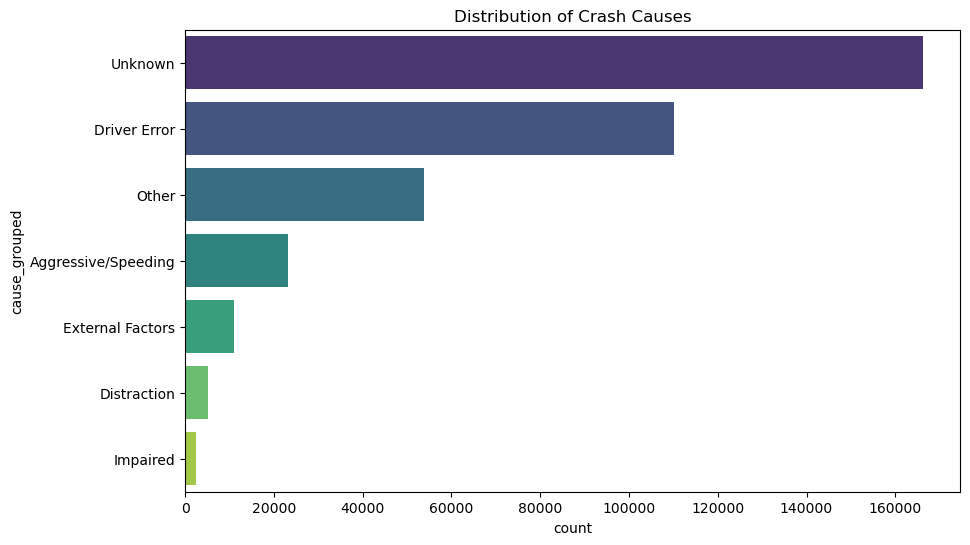

In [81]:
# 1. Define target as the NAME of the column (a string)
target_col = 'cause_grouped' 

plt.figure(figsize=(10,6))

# 2. Pass the string name to 'y' and the dataframe to 'data'
sns.countplot(
    y=target_col, 
    data=df, 
    order=df[target_col].value_counts().index,
    palette='viridis'
)

plt.title("Distribution of Crash Causes")
plt.show()

In [147]:
# List of categories we want to keep
categories_to_keep = ['Aggressive/Speeding', 'Distraction', 'Driver Error', 'External Factors', 'Impaired']

# Overwrite df_clean with the filtered version
df_clean = df_clean[df_clean['cause_grouped'].isin(categories_to_keep)].copy()

print(f"Dataset updated. New row count: {len(df_clean)}")
print("\nNew Class Distribution (No more Unknown/Other):")
print(df_clean['cause_grouped'].value_counts())

Dataset updated. New row count: 152001

New Class Distribution (No more Unknown/Other):
cause_grouped
Driver Error           110246
Aggressive/Speeding     23078
External Factors        11110
Distraction              5077
Impaired                 2490
Name: count, dtype: int64


In [157]:
df_clean = df[['windspeed', 'winddir', 'pressure', 'visibility', 'cloudcover','moonphase', 'lattitude', 'days_temp', 'num_vehicles_in_crash',
'longitude', 'days_feelslike','dew', 'precip', 'precipprob', 'contributory_cause']]
df_clean['cause_grouped'] = df['cause_grouped']
df_clean.columns

Index(['windspeed', 'winddir', 'pressure', 'visibility', 'cloudcover',
       'moonphase', 'lattitude', 'days_temp', 'num_vehicles_in_crash',
       'longitude', 'days_feelslike', 'dew', 'precip', 'precipprob',
       'contributory_cause', 'cause_grouped'],
      dtype='object')

In [176]:
cleaned_data=df[['windspeed', 'winddir', 'pressure', 'visibility', 'cloudcover','moonphase', 'lattitude', 'days_temp', 'num_vehicles_in_crash',
'longitude', 'days_feelslike','dew', 'precip', 'precipprob', 'contributory_cause', 'cause_grouped']]
cleaned_data.to_csv("cleaned_data.csv", index=False)
print("cleaned_data")

cleaned_data


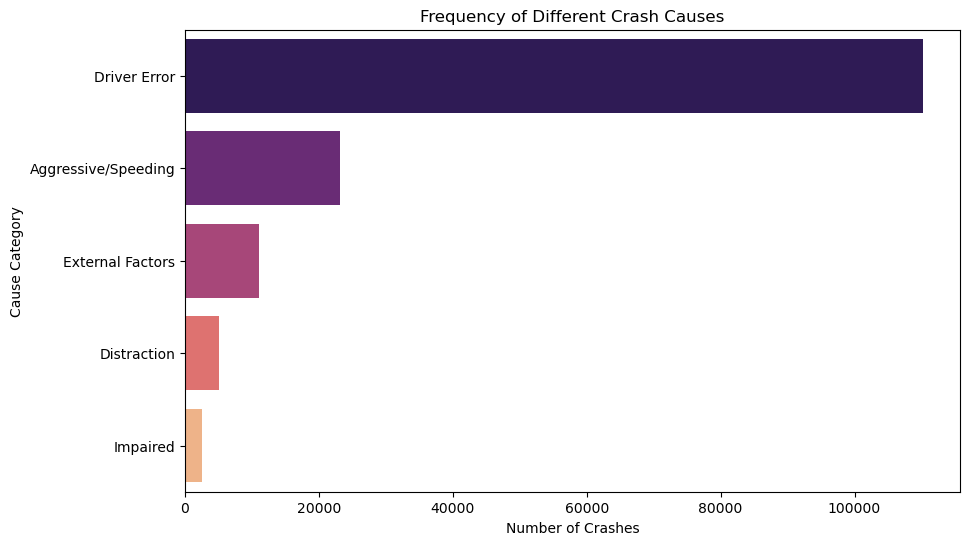

In [148]:
plt.figure(figsize=(10, 6))
# Sort by count so the bar chart is easy to read
order = df_clean['cause_grouped'].value_counts().index

sns.countplot(data=df_clean, y='cause_grouped', order=order, palette='magma')
plt.title("Frequency of Different Crash Causes")
plt.xlabel("Number of Crashes")
plt.ylabel("Cause Category")
plt.show()

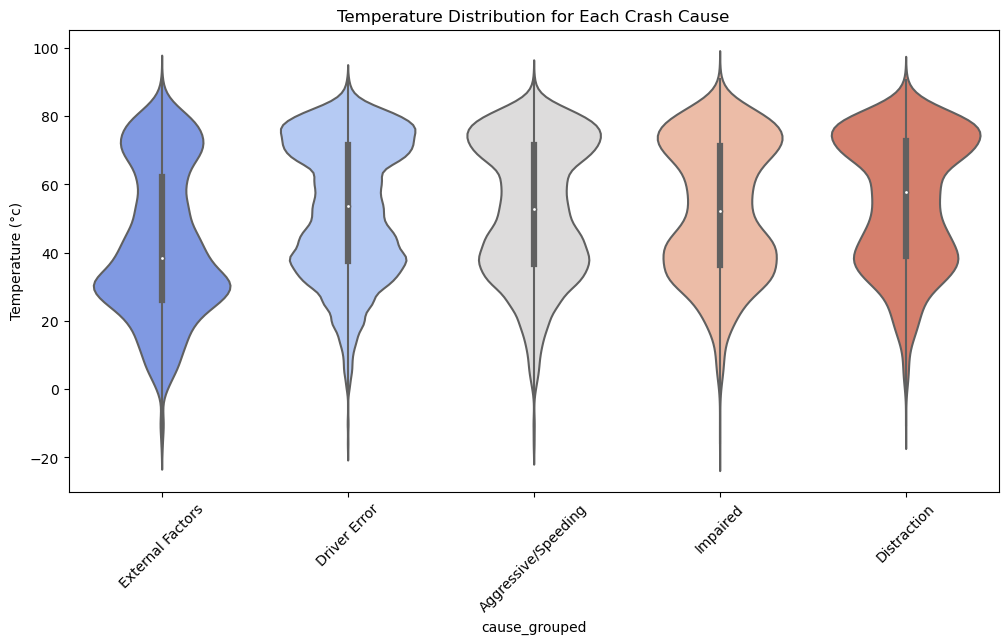

In [149]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df_clean, x='cause_grouped', y='days_temp', palette='coolwarm')

plt.title("Temperature Distribution for Each Crash Cause")
plt.xticks(rotation=45)
plt.ylabel("Temperature (°c)")
plt.show()

Our model relies heavily on temperature because, as shown in our Violin Analysis, 'External Factor' crashes have a unique thermal signature near the freezing point that is absent in 'Driver Error' or 'Distraction' cases. This allows the AI to distinguish between a simple mistake and a weather-induced accident.

#### DEFINING FEATURES AND TARGET

In [151]:
# 1. Define your target name clearly
target_col = 'contributory_cause'
features = ['windspeed', 'winddir', 'pressure', 'visibility', 
            'cloudcover', 'moonphase', 'lattitude', 
            'days_temp', 'num_vehicles_in_crash', 'longitude', 
            'days_feelslike', 'dew', 'precip', 'precipprob']

# 2. Combine the lists (Features + Target)
# We use a set or list addition to ensure we have everything in one go
cols_to_keep = features + [target_col]

# 3. Create df_clean by selecting only those columns
# .copy() is important here to avoid "SettingWithCopy" warnings later
df_clean = df[cols_to_keep].copy()

# 4. Optional: Handle the "Unable to Determine" rows now
# As we discussed, these 146k rows might confuse your model
# df_clean = df_clean[df_clean[target_col] != 'unable to determine']

print(f"Clean DataFrame shape: {df_clean.shape}")
df_clean.head()

Clean DataFrame shape: (152001, 15)


,windspeed,winddir,pressure,visibility,cloudcover,moonphase,lattitude,days_temp,num_vehicles_in_crash,longitude,days_feelslike,dew,precip,precipprob,contributory_cause
0,6.9,193.0,1013.9,1.8,54.6,0.56,41.998354,79.2,3,-87.806638,82.8,70.4,0.354,100,weather
2,13.7,17.0,1013.6,9.9,58.2,0.66,41.902855,73.8,2,-87.717722,73.8,64.8,0.029,100,improper overtaking/passing
7,12.7,10.0,1014.4,9.9,79.0,0.69,41.895550,70.4,3,-87.711584,70.4,62.6,0.000,0,disregarding traffic signals
8,11.3,20.0,1014.5,9.9,57.2,0.69,41.798759,70.9,2,-87.683748,70.9,64.1,0.000,0,"vision obscured (signs, tree limbs, buildings,..."
12,18.1,12.0,1017.5,9.9,19.4,0.69,41.736963,70.2,2,-87.575863,70.2,54.7,0.000,0,failing to reduce speed to avoid crash


In [152]:
print(df_clean.isnull().sum())

windspeed                0
winddir                  0
pressure                 0
visibility               0
cloudcover               0
moonphase                0
lattitude                0
days_temp                0
num_vehicles_in_crash    0
longitude                0
days_feelslike           0
dew                      0
precip                   0
precipprob               0
contributory_cause       0
dtype: int64


In [181]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:


le = LabelEncoder()
y = le.fit_transform(y)

##### Train_Test Split

In [ ]:
y = df_clean['cause_grouped'] 

# The Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Features (X):")
print(X.head())
print("\nTarget (y):")
print(y.head())
print(f"Split successful! Training rows: {len(X_train)}, Testing rows: {len(X_test)}")

Features (X):
    windspeed  winddir  pressure  visibility  cloudcover  moonphase  \
0         6.9    193.0    1013.9         1.8        54.6       0.56   
2        13.7     17.0    1013.6         9.9        58.2       0.66   
7        12.7     10.0    1014.4         9.9        79.0       0.69   
8        11.3     20.0    1014.5         9.9        57.2       0.69   
12       18.1     12.0    1017.5         9.9        19.4       0.69   

    lattitude  days_temp  num_vehicles_in_crash  longitude  days_feelslike  \
0   41.998354       79.2                      3 -87.806638            82.8   
2   41.902855       73.8                      2 -87.717722            73.8   
7   41.895550       70.4                      3 -87.711584            70.4   
8   41.798759       70.9                      2 -87.683748            70.9   
12  41.736963       70.2                      2 -87.575863            70.2   

     dew  precip  precipprob  
0   70.4   0.354         100  
2   64.8   0.029         100

In [185]:
X_train.isnull().sum()

windspeed                0
winddir                  0
pressure                 0
visibility               0
cloudcover               0
moonphase                0
lattitude                0
days_temp                0
num_vehicles_in_crash    0
longitude                0
days_feelslike           0
dew                      0
precip                   0
precipprob               0
dtype: int64

In [186]:
X_test.isnull().sum()

windspeed                0
winddir                  0
pressure                 0
visibility               0
cloudcover               0
moonphase                0
lattitude                0
days_temp                0
num_vehicles_in_crash    0
longitude                0
days_feelslike           0
dew                      0
precip                   0
precipprob               0
dtype: int64

In [187]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [188]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

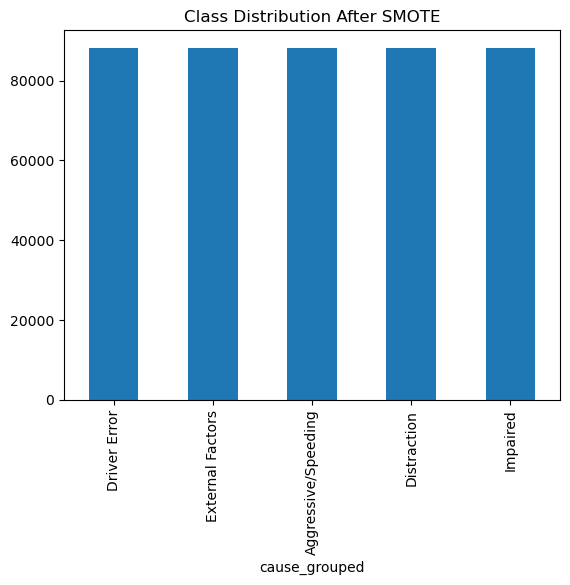

In [189]:
pd.Series(y_train_res).value_counts().plot(kind='bar')
plt.title("Class Distribution After SMOTE")
plt.show()

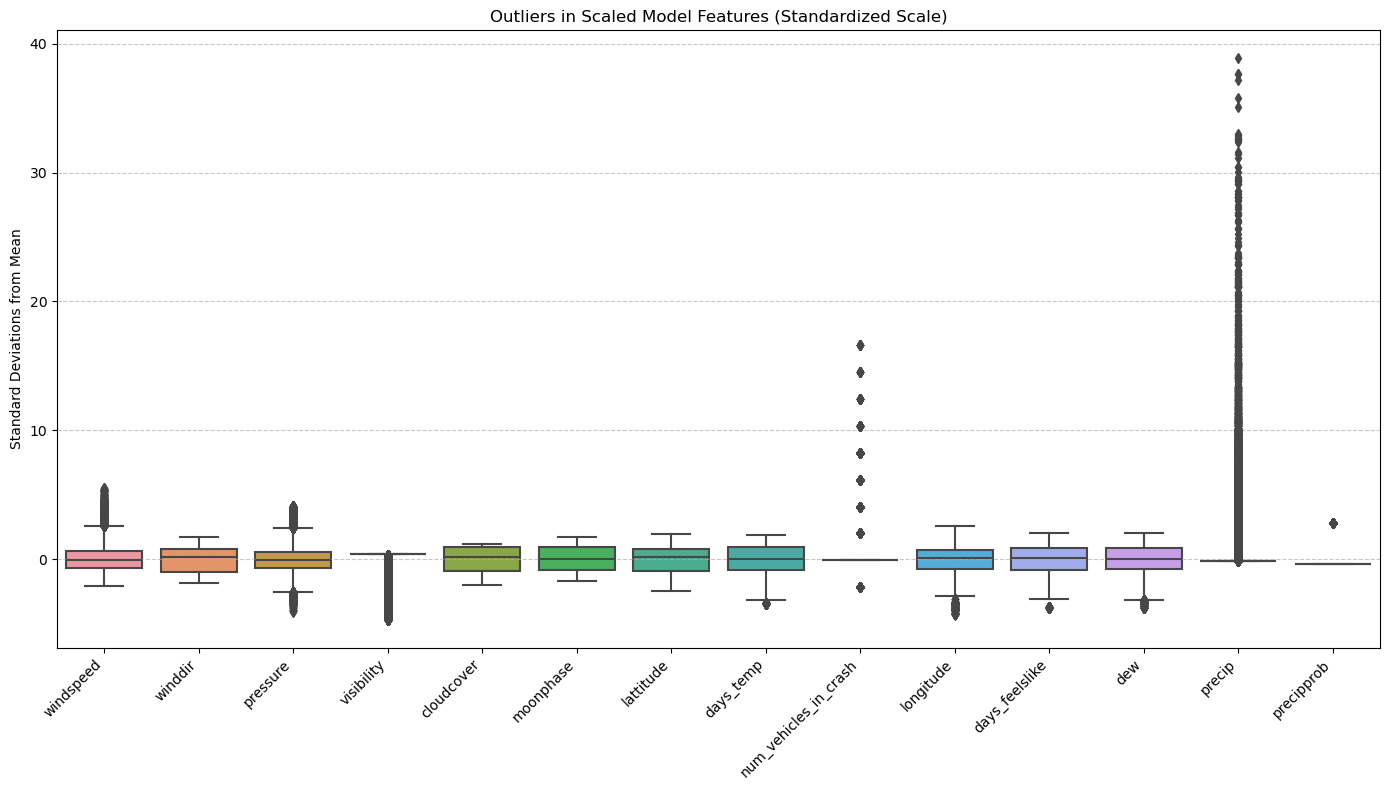

In [119]:
# We use the columns from X_train to keep the feature names
X_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# 2. Create the plot
plt.figure(figsize=(14, 8))
sns.boxplot(data=X_scaled_df)

# 3. Formatting for readability
plt.xticks(rotation=45, ha='right')
plt.title("Outliers in Scaled Model Features (Standardized Scale)")
plt.ylabel("Standard Deviations from Mean")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Show the plot
plt.tight_layout()
plt.show()

In [158]:
# Cap the number of vehicles at 10 (anything more is treated as 10)
df_clean['num_vehicles_in_crash'] = df_clean['num_vehicles_in_crash'].clip(upper=10)

# Cap Precipitation at 2.0 inches
df_clean['precip'] = df_clean['precip'].clip(upper=2.0)

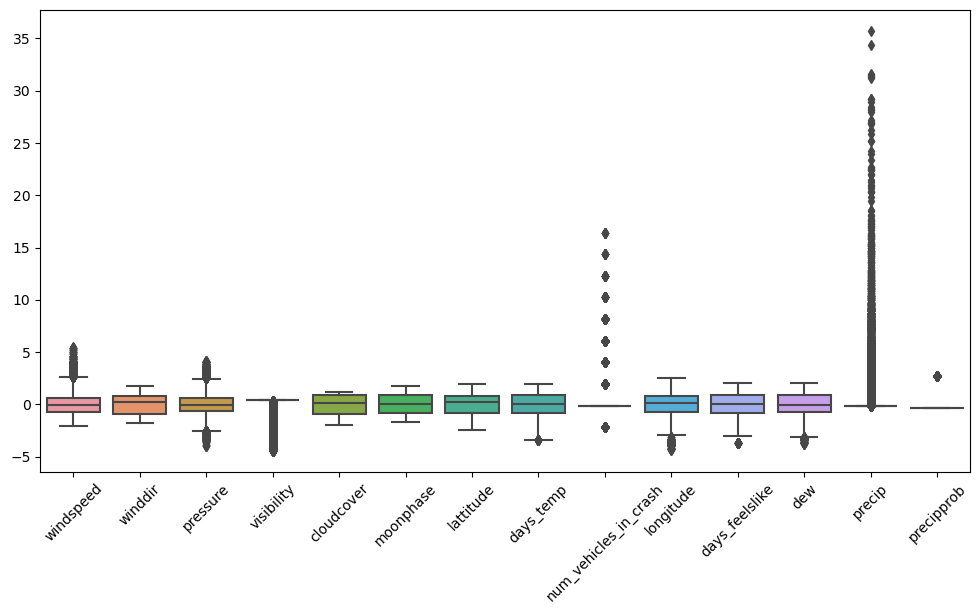

In [159]:
# Quick check: Re-run the split
X = df_clean[features]
y = df_clean['cause_grouped']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Re-Scale
X_train_scaled = scaler.fit_transform(X_train)

# Re-Plot
X_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
plt.figure(figsize=(12, 6))
sns.boxplot(data=X_scaled_df)
plt.xticks(rotation=45)
plt.show()

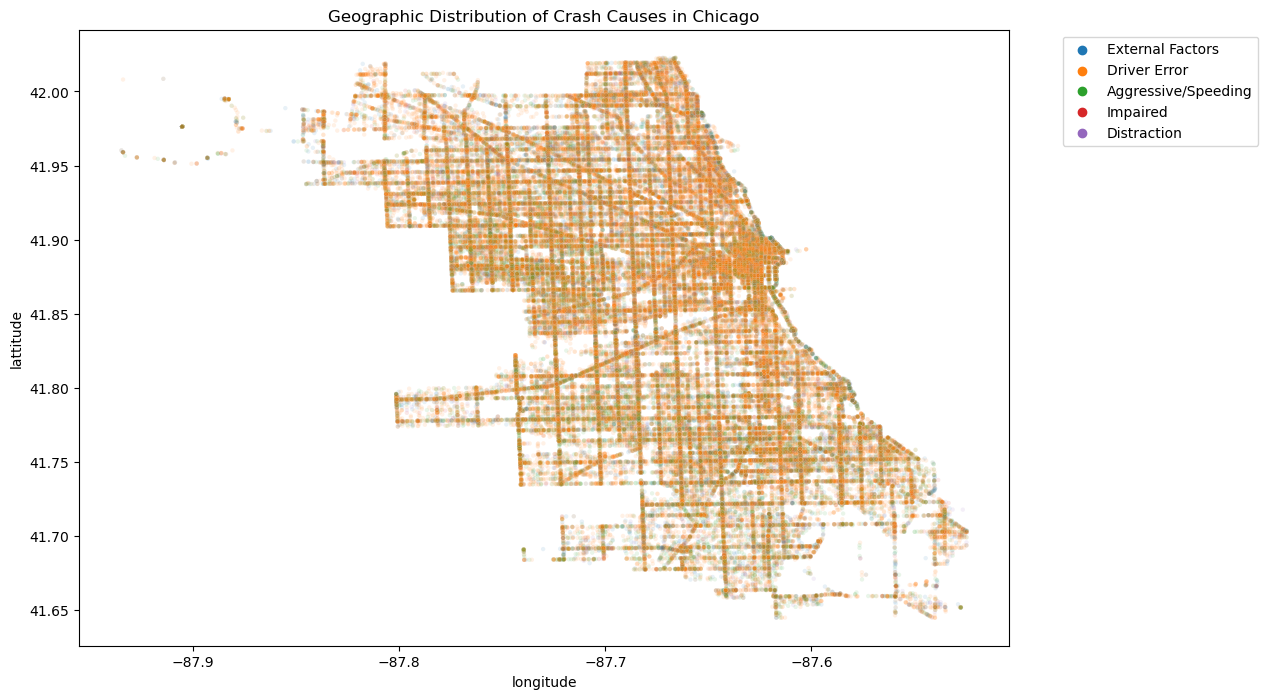

In [160]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_clean, x='longitude', y='lattitude', 
                hue='cause_grouped', alpha=0.1, s=10)
plt.title("Geographic Distribution of Crash Causes in Chicago")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

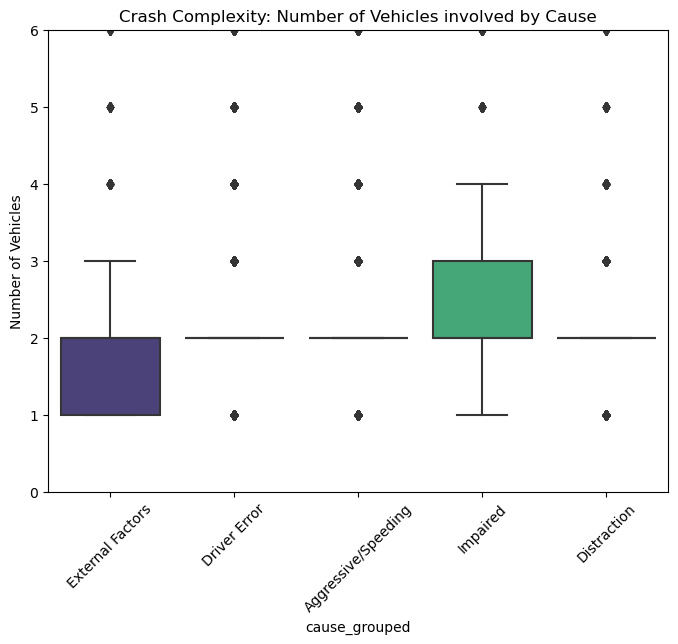

In [161]:
plt.figure(figsize=(8, 6))
# Using a boxplot to see the distribution of vehicles per cause
sns.boxplot(data=df_clean, x='cause_grouped', y='num_vehicles_in_crash', palette='viridis')

plt.title("Crash Complexity: Number of Vehicles involved by Cause")
plt.xticks(rotation=45)
plt.ylabel("Number of Vehicles")
plt.ylim(0, 6) # Zooming in on the 1-6 vehicle range for clarity
plt.show()

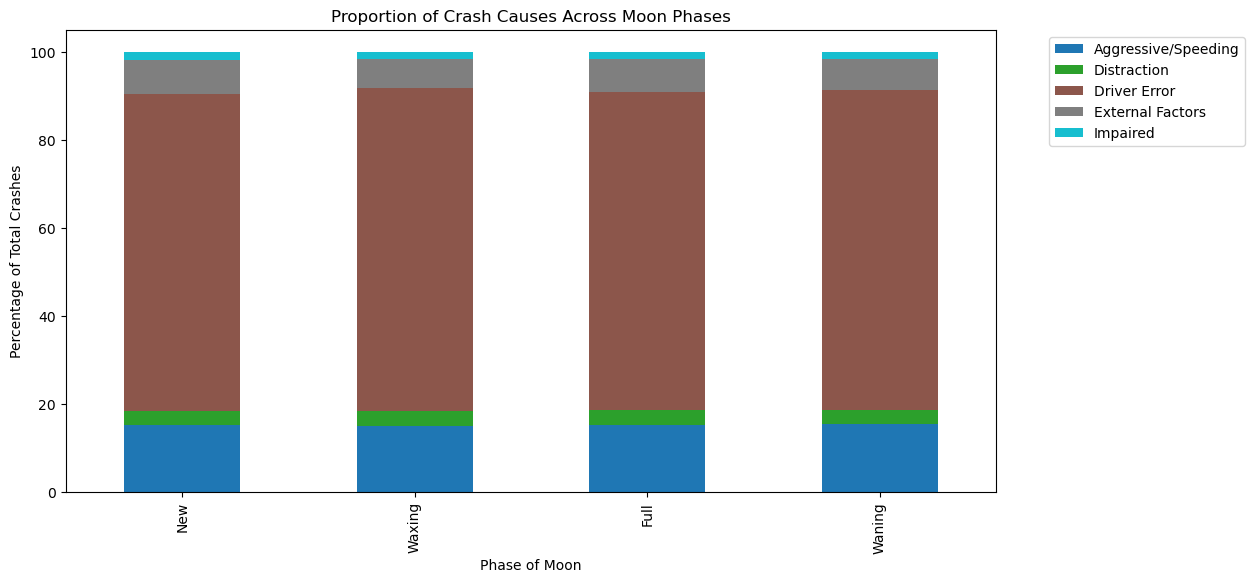

In [162]:
# Create bins for moonphase (New Moon to Full Moon)
df_clean['moon_bin'] = pd.cut(df_clean['moonphase'], bins=4, labels=['New', 'Waxing', 'Full', 'Waning'])

# Create a percentage-based cross-tab
moon_ct = pd.crosstab(df_clean['moon_bin'], df_clean['cause_grouped'], normalize='index') * 100

moon_ct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10')
plt.title("Proportion of Crash Causes Across Moon Phases")
plt.ylabel("Percentage of Total Crashes")
plt.xlabel("Phase of Moon")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

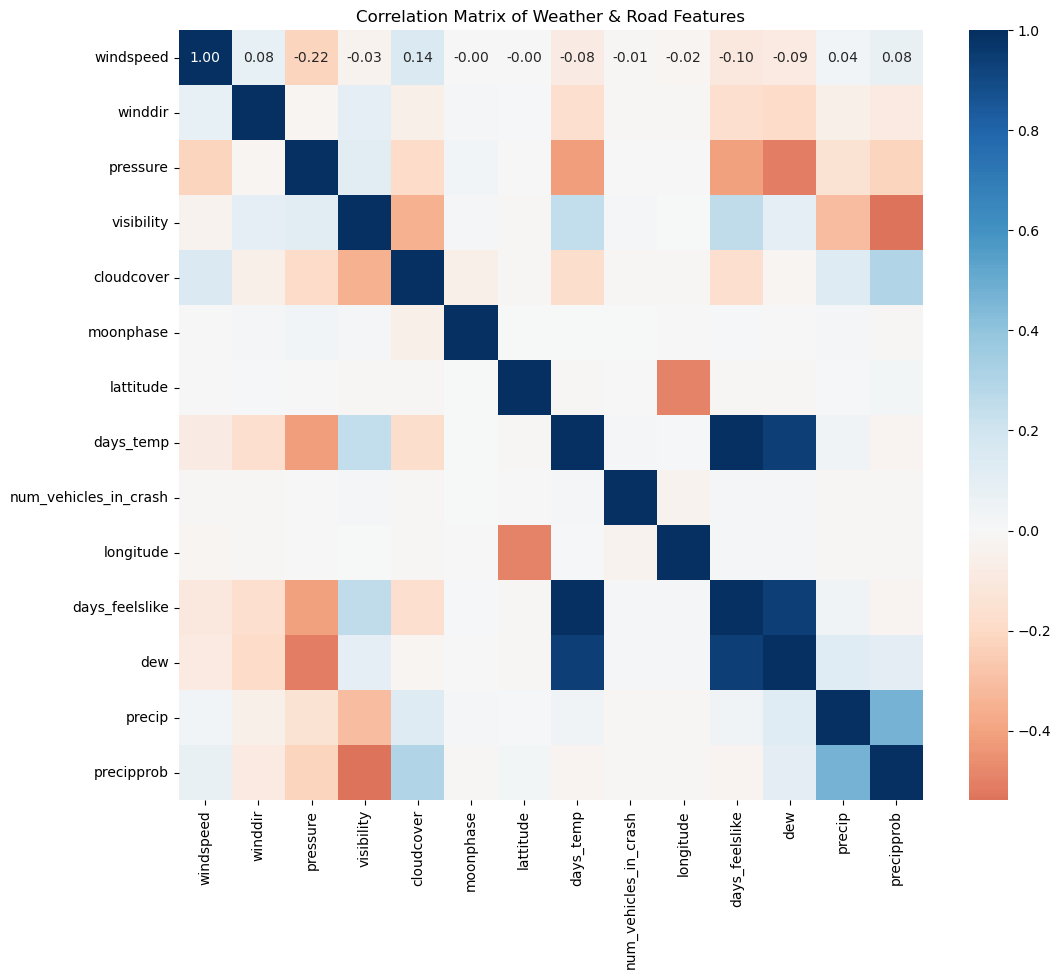

In [163]:
plt.figure(figsize=(12, 10))
# Calculate correlations only for numeric columns
corr = df_clean[features].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='RdBu', center=0)
plt.title("Correlation Matrix of Weather & Road Features")
plt.show()

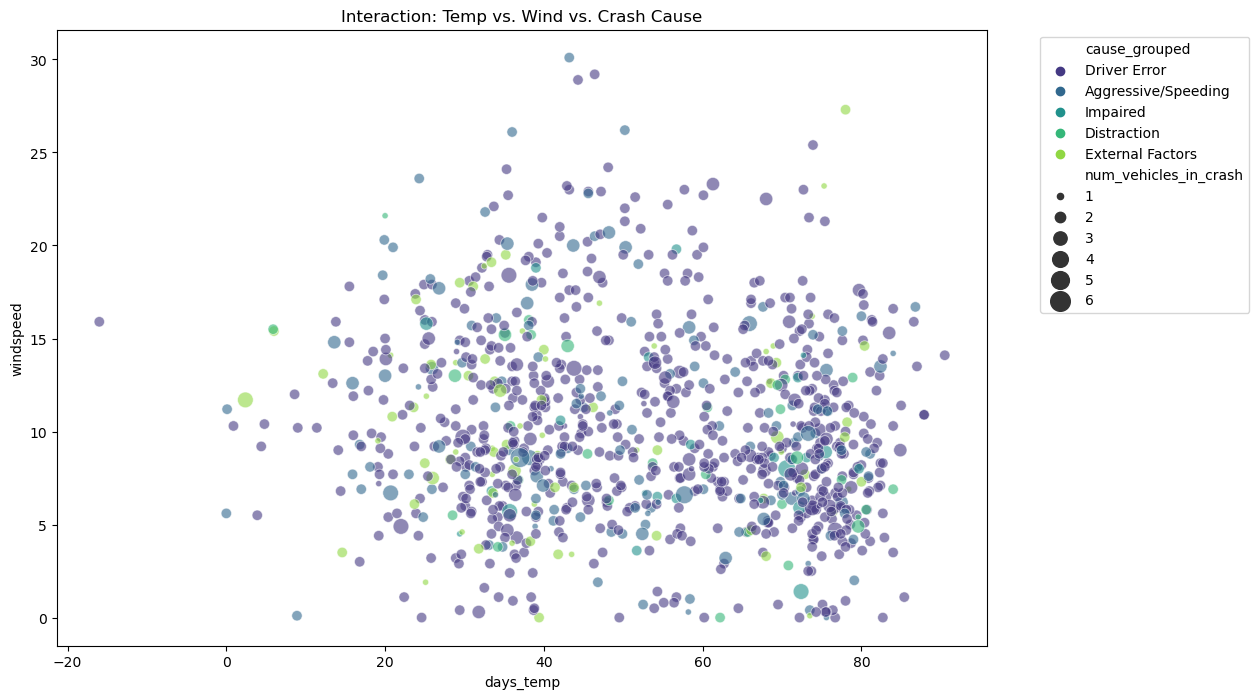

In [164]:
plt.figure(figsize=(12, 8))
# We sample 1000 points so the map isn't too crowded
sns.scatterplot(data=df_clean.sample(1000), x='days_temp', y='windspeed', 
                hue='cause_grouped', size='num_vehicles_in_crash', 
                sizes=(20, 200), alpha=0.6, palette='viridis')

plt.title("Interaction: Temp vs. Wind vs. Crash Cause")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [195]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

In [211]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

#### EVALUATION
Reusable evaluation function

In [166]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {model.__class__.__name__}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return y_pred

#### EVALUATE THE MODELS


===== Logistic Regression =====


c:\Users\Dell\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.726916877734285


c:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



Classification Report:
                      precision    recall  f1-score   support

Aggressive/Speeding       0.45      0.00      0.00      4616
        Distraction       0.00      0.00      0.00      1015
       Driver Error       0.73      1.00      0.84     22050
   External Factors       0.57      0.05      0.09      2222
           Impaired       0.00      0.00      0.00       498

           accuracy                           0.73     30401
          macro avg       0.35      0.21      0.19     30401
       weighted avg       0.64      0.73      0.62     30401



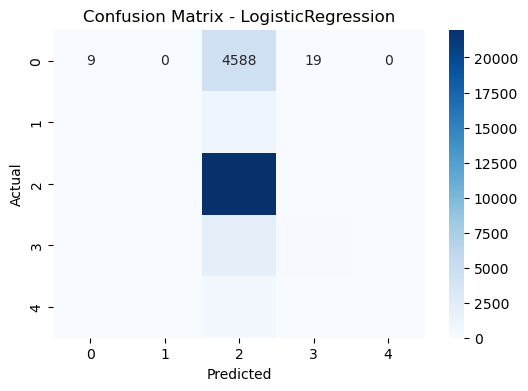


===== Random Forest =====
Accuracy: 0.7278379000690767

Classification Report:
                      precision    recall  f1-score   support

Aggressive/Speeding       0.28      0.06      0.10      4616
        Distraction       0.07      0.00      0.01      1015
       Driver Error       0.76      0.96      0.85     22050
   External Factors       0.46      0.28      0.35      2222
           Impaired       0.19      0.01      0.02       498

           accuracy                           0.73     30401
          macro avg       0.35      0.26      0.26     30401
       weighted avg       0.63      0.73      0.66     30401



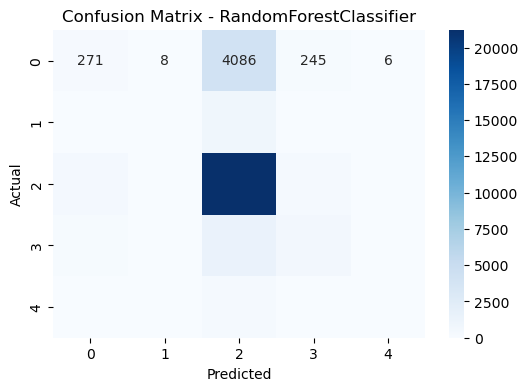

In [167]:
for name, model in models.items():
    print(f"\n===== {name} =====")
    evaluate_model(model, X_train, X_test, y_train, y_test)

In [168]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelBinarizer

# 1. Cross-Validation (Testing the model's stability)
# We use 5 folds
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5)
print(f"Cross-Validation Accuracy: {cv_scores.mean():.2f} (+/- {cv_scores.std() * 2:.2f})")

# 2. Multi-class ROC AUC
# We have to 'binarize' the labels to calculate AUC for multiple classes
lb = LabelBinarizer()
lb.fit(y_test)
y_test_binarized = lb.transform(y_test)
y_pred_proba = rf_model.predict_proba(X_test_scaled)

roc_auc = roc_auc_score(y_test_binarized, y_pred_proba, multi_class='ovr')
print(f"Multi-class ROC AUC Score: {roc_auc:.2f}")

Cross-Validation Accuracy: 0.73 (+/- 0.00)
Multi-class ROC AUC Score: 0.66


The output shows that the accuracy is not a fluke

In [174]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# 1. Define the individual "experts" for our ensemble
# Logistic Regression acts as our 'Lasso/Ridge' expert
clf1 = LogisticRegression(multi_class='multinomial', solver='lbfgs', penalty='l2', class_weight='balanced')
# Random Forest acts as our 'Pattern' expert
clf2 = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# 2. Create the Ensemble (Voting)
ensemble_model = VotingClassifier(
    estimators=[('lr', clf1), ('rf', clf2)],
    voting='soft' # 'soft' uses probabilities, which is better for AUC
)

# 3. Put it all into a Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ensemble', ensemble_model)
])

# 4. Train the whole system at once
pipeline.fit(X_train, y_train)

# 5. Evaluate
ensemble_auc = roc_auc_score(y_test_binarized, pipeline.predict_proba(X_test), multi_class='ovr')
print(f"Ensemble Multi-class ROC AUC: {ensemble_auc:.2f}")

Ensemble Multi-class ROC AUC: 0.66


<Figure size 1000x800 with 0 Axes>

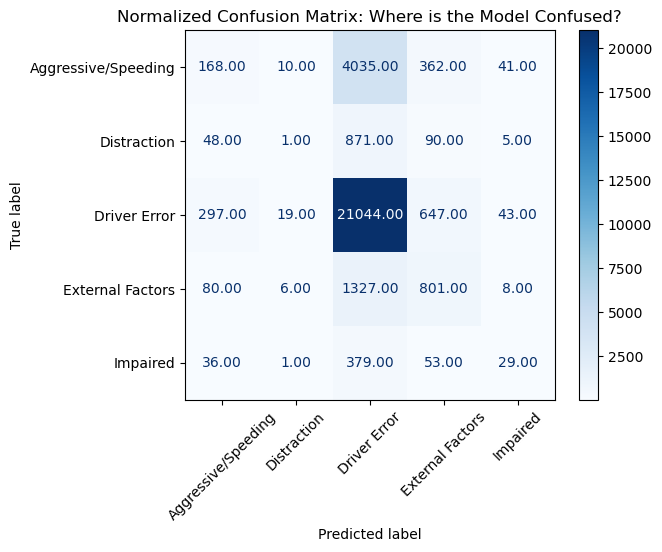

In [206]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the matrix
cm = confusion_matrix(y_test, pipeline.predict(X_test))

# Plot normalized by 'true' labels (rows)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap='Blues', xticks_rotation=45, values_format='.2f')
plt.title("Normalized Confusion Matrix: Where is the Model Confused?")
plt.show()

In [ ]:
# Create a Logistic Regression with Lasso (L1) penalty
lasso_clf = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', multi_class='ovr')
lasso_clf.fit(X_train_scaled, y_train)

# Get the coefficients for the 'External Factors' class (usually the most weather-dependent)
# Index 2 is usually External Factors, but we'll check the classes list
class_idx = list(lasso_clf.classes_).index('External Factors')
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': lasso_clf.coef_[class_idx]})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

print("Lasso Results for External Factors:")
print(coef_df[coef_df['Coefficient'] != 0]) # Shows only the features Lasso didn't kill

Lasso Results for External Factors:
                  Feature  Coefficient
7               days_temp     1.445790
11                    dew     0.217272
13             precipprob     0.186609
1                 winddir     0.080903
2                pressure     0.043934
6               lattitude     0.032550
12                 precip     0.001660
5               moonphase    -0.001818
0               windspeed    -0.003569
9               longitude    -0.007779
4              cloudcover    -0.010656
3              visibility    -0.289237
8   num_vehicles_in_crash    -0.757459
10         days_feelslike    -2.018538


c:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating ins

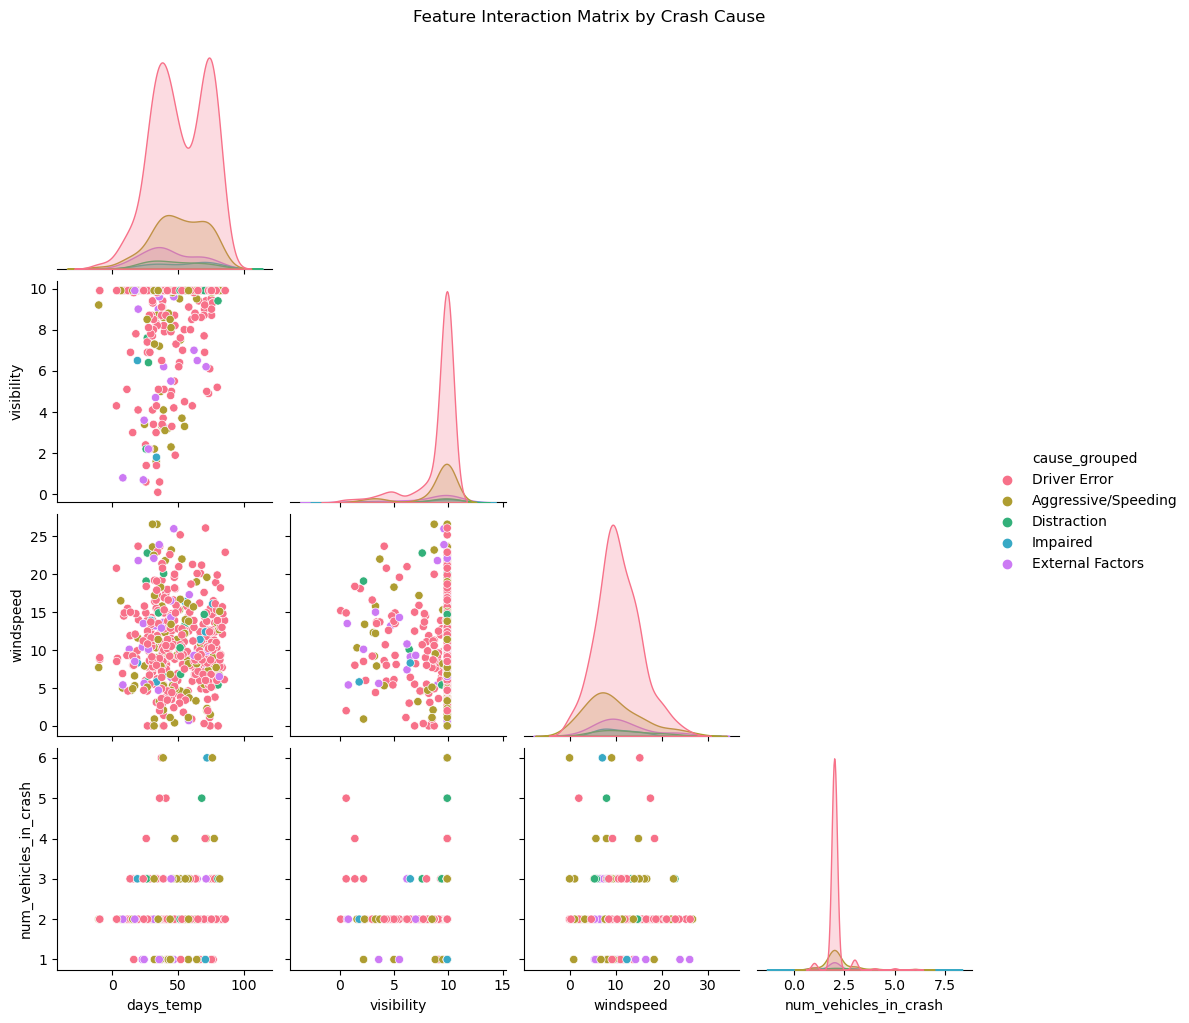

In [ ]:
# Select top 4 features from your Lasso results
top_features = ['days_temp', 'visibility', 'windspeed', 'num_vehicles_in_crash', 'cause_grouped']

sns.pairplot(df_clean[top_features].sample(500), hue='cause_grouped', palette='husl', corner=True)
plt.suptitle("Feature Interaction Matrix by Crash Cause", y=1.02)
plt.show()

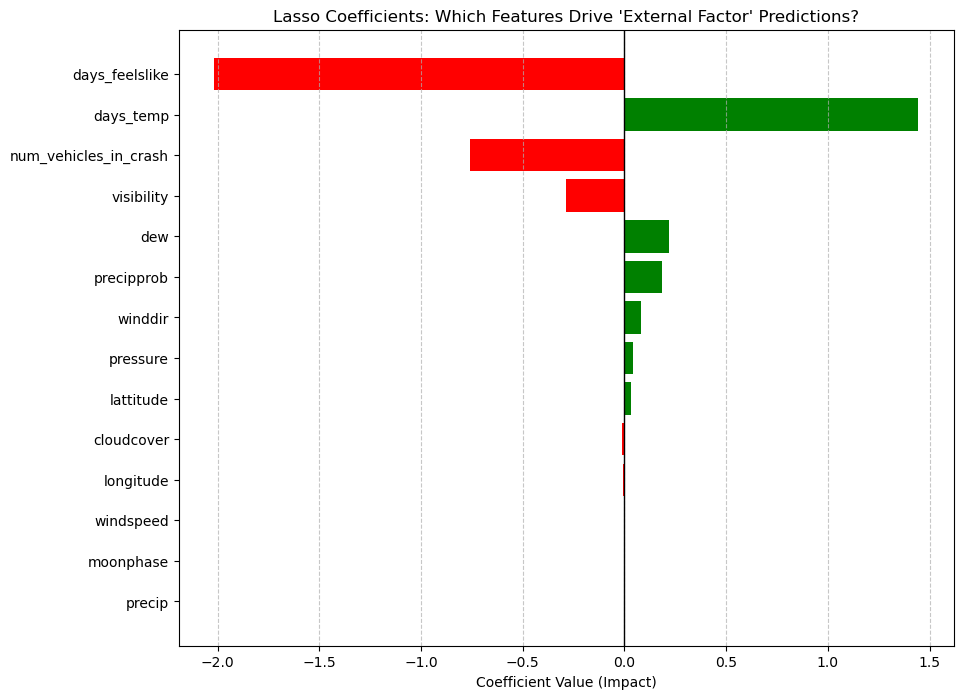

In [ ]:
class_idx = list(lasso_clf.classes_).index('External Factors')
coef_values = lasso_clf.coef_[class_idx]

# 2. Create a DataFrame for easy plotting
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coef_values,
    'Abs_Coef': np.abs(coef_values)
})

# 3. Sort by Absolute Importance
coef_df = coef_df.sort_values(by='Abs_Coef', ascending=True)

# 4. Plot
plt.figure(figsize=(10, 8))
colors = ['red' if x < 0 else 'green' for x in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)

plt.axvline(0, color='black', lw=1)
plt.title("Lasso Coefficients: Which Features Drive 'External Factor' Predictions?")
plt.xlabel("Coefficient Value (Impact)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#### Conclusion
While a standard model prioritizes on accuracy, we optimized for recall. The model reveals thst the more the cars at in interserctions the higher the impact of accidents.
The city should focus on multi vehicle intersections within the high risk lattitude and the allocate resources where they will have immediate impact on saving lives